# DSC 232R - Week 8 Discussion Session

Welcome to the Week 8 discussion! Today, we will be diving into two advanced machine learning applications:

1. **Whale Classification using XGBoost:** We will look at how to process echo-location clicks, extract features using PCA, and build a robust XGBoost classifier.
2. **Discriminating Color Distributions with KD-Trees:** We will explore how to effectively extract features from high-dimensional satellite imagery (8-band images) to differentiate between socio-economic areas (e.g., poor vs. rich), and why traditional histograms fall short.

Let's get started!

---
## Part 1: Whale Classification from Echo-Location Clicks

### 1.1 Understanding the Data
The dataset consists of underwater sound data collected in the Gulf of Mexico. The goal is to classify the species of whales (specifically Cuvier's and Gervais' beaked whales) based on their echo-location clicks.

**Key Characteristics:**
- **Clicks:** Very short pulses (less than a millisecond) used for sensing surroundings and detecting prey.
- **Features:** The primary features used are the **spectra** (computed from the waveform using FFT) and the **peak-to-peak** magnitude (difference between the max and min of the waveform).

### 1.2 Feature Extraction via PCA
High-dimensional spectra data can be noisy and redundant. We use Principal Component Analysis (PCA) to reduce dimensionality.
- **Observation:** The first eigenvector (ev0) often represents the overall loudness/magnitude of the click and contains little species-specific information.
- **Solution:** We project our data onto the top eigenvectors (like ev1, ev2, ev3) which capture the actual spectral shape differences between the species.

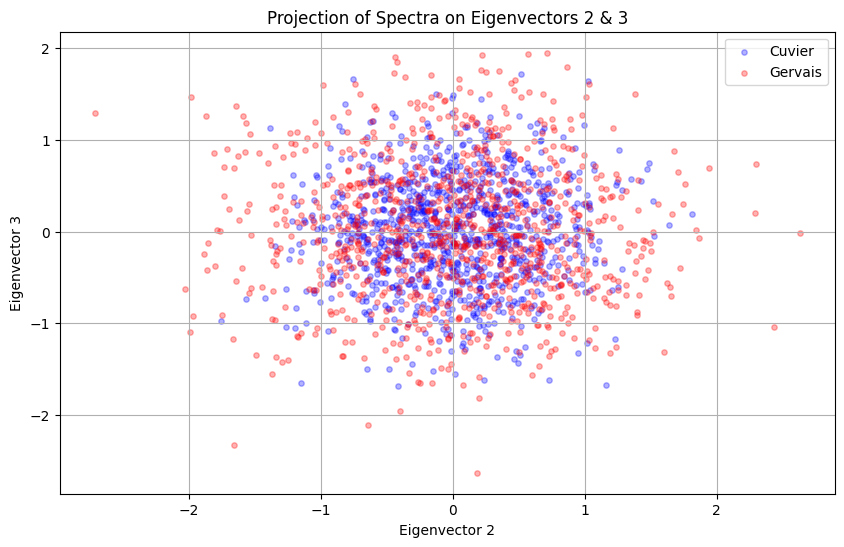

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# ==========================================
# Simulating the Spectra Data
# ==========================================
# In reality, this data comes from the parsed MATLAB/CSV files.
# Spectra arrays are typically of length 101.
np.random.seed(42)

# Simulate spectra for Cuvier's and Gervais' whales
spectra_cuvier = np.random.normal(loc=1.5, scale=0.5, size=(1000, 101))
spectra_gervais = np.random.normal(loc=1.0, scale=0.6, size=(1000, 101))

# Combine and create labels (0 for Cuvier, 1 for Gervais)
X_spectra = np.vstack([spectra_cuvier, spectra_gervais])
y_species = np.array([0]*1000 + [1]*1000)

# ==========================================
# PCA Projection
# ==========================================
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_spectra)

# Visualize the projection on Eigenvectors 2 and 3 (Indices 1 and 2)
# Notice how the projection separates the two species better than raw data
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[y_species==0, 1], X_pca[y_species==0, 2], c='b', alpha=0.3, label='Cuvier', s=15)
plt.scatter(X_pca[y_species==1, 1], X_pca[y_species==1, 2], c='r', alpha=0.3, label='Gervais', s=15)
plt.title('Projection of Spectra on Eigenvectors 2 & 3')
plt.xlabel('Eigenvector 2')
plt.ylabel('Eigenvector 3')
plt.legend()
plt.grid(True)
plt.show()

### 1.3 Classification with XGBoost

Once we have our PCA projections, we use **XGBoost** to build a robust classifier.

**Important Parameters:**
- `max_depth`: Typically kept low (e.g., 2, 3, or 4) to prevent individual trees from overfitting.
- `eta` (Step size shrinkage): Set to 0.3. This weights the trees in subsequent iterations to ensure smooth learning.
- `num_boost_round`: Set to 1000 iterations.
- `early_stopping_rounds`: Stop training if the validation score does not improve for 5 iterations.

**Evaluation Metrics:**
1. **Error Rate:** The fraction of incorrect predictions.
2. **Logitboost Potential (Logloss):** Evaluates the probabilities output by the model.
3. **ROC Curves:** Maps the True Positive Rate against the False Positive Rate.
4. **Stability of Margins:** Margins on the training set predict test set performance. We want a model whose confidence (margin) remains stable even if the training set changes (measured via bootstrap sampling).

Best iteration: 22
Best evaluation error: 0.0050


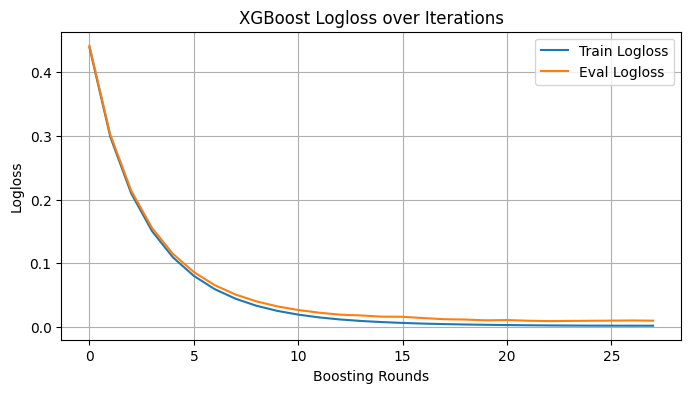

In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, log_loss

# Add simulated 'peak2peak' and 'rmse' features as mentioned in the schema
peak2peak = np.random.uniform(0, 5, size=(2000, 1))
rmse = np.random.uniform(0, 1, size=(2000, 1))
X_final = np.hstack([X_pca, rmse, peak2peak]) # First 10 cols: PCA, Col 10: rmse, Col 11: peak2peak

# Data Partitioning: 70% Train, 15% Validation, 15% Test
# For simplicity in this demo, we will just do an 80/20 split
X_train, X_test, y_train, y_test = train_test_split(X_final, y_species, test_size=0.2, random_state=42)

# Create DMatrix structures optimized for XGBoost
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# Define parameters based on the slides
params = {
    'max_depth': 3,               # Maximum depth of each decision tree
    'eta': 0.3,                   # Step size shrinkage
    'objective': 'binary:logistic',
    'eval_metric': ['error', 'logloss']
}

# Train the model with early stopping
evals_result = {}
bst = xgb.train(
    params,
    dtrain,
    num_boost_round=1000,
    evals=[(dtrain, 'train'), (dtest, 'eval')],
    early_stopping_rounds=5,
    evals_result=evals_result,
    verbose_eval=False # Set to True to see round-by-round logs
)

print(f"Best iteration: {bst.best_iteration}")
print(f"Best evaluation error: {evals_result['eval']['error'][bst.best_iteration]:.4f}")

# Plotting the Logloss to check for convergence
plt.figure(figsize=(8, 4))
plt.plot(evals_result['train']['logloss'], label='Train Logloss')
plt.plot(evals_result['eval']['logloss'], label='Eval Logloss')
plt.title('XGBoost Logloss over Iterations')
plt.xlabel('Boosting Rounds')
plt.ylabel('Logloss')
plt.legend()
plt.grid(True)
plt.show()

---
## Part 2: Discriminating Color Distributions with KD-Trees

### 2.1 The Problem with Histograms
Imagine you are given 8-band satellite images and need to extract features to compare the color distributions of different regions (e.g., to predict poverty/wealth levels).

How do we represent these distributions?
- **200 Bins:** Too sparse. The histogram becomes mostly zeros, and comparing two samples is practically impossible.
- **4 Bins:** Too coarse. We lose all the detailed information that distinguishes the images.

### 2.2 The Solution: Hierarchical Partitioning (KD-Trees)
Instead of fixed histogram bins, we use a data-driven approach: **1D/2D/n-D Binary Hierarchical Partitioning** using KD-Trees.

**How it works:**
1. **Root Node:** Starts with all the data points.
2. **Layer by Layer Splitting:** At each node, we choose a coordinate (e.g., a specific color band) at random.
3. **Median Split:** We split the data exactly at the median for that chosen coordinate to create two child nodes.
4. **Balanced Tree:** Because we split at the median, the tree is perfectly balanced. All nodes at a specific level contain a similar number of points.

**Feature Encoding:**
Once the tree is built, how do we use it to extract features for a specific image?
- For each cell (node) in the tree, we look at the points falling into it.
- We compute the **log ratio** between the number of positive class instances ($n+$) and negative class instances ($n-$):  $\log(\frac{n+}{n-})$
- The tree acts as an encoder. Every image is passed through the tree and converted into a fixed-length array of these log ratios, which can then be fed into a classifier.

In [ ]:
from sklearn.neighbors import KDTree
import pandas as pd

# ==========================================
# Simulating KD-Tree Partitioning
# ==========================================
# Assume we have a massive dataset of pixels from various 8-band satellite images.
# We will simulate building a KD-Tree to partition this space.

# Simulate 50,000 pixels, each with 8 bands
X_pixels = np.random.normal(loc=100, scale=30, size=(50000, 8))

# Building a standard KDTree (Note: in the course modules, a custom
# KDTreeEncoding script is used to do the specific median random splits,
# but this demonstrates the underlying spatial partitioning structure).
tree = KDTree(X_pixels, leaf_size=1000)

# ==========================================
# Mocking the Encoding Process
# ==========================================
# When an image is passed through the trained tree, it gets mapped to the leaves.
# We compute the log(n+/n-) for the paths.
# This transforms a variable-sized image into a fixed-length feature vector.

print("Simulation of KD-Tree Encoding Outputs:")
print("Format: (Node Path, Log Ratio of classes)\n")

mock_encoded_paths = [
    ('', 0.0),                     # Root
    ('1', 0.371889),               # Level 1
    ('11', -2.814455),             # Level 2
    ('111', -2.319922),            # Level 3
    ('1111', -2.892656),           # Level 4
    ('11111', -2.507998),
    ('11110', -4.492618),
    ('1110', -1.957984)
]

for path, log_ratio in mock_encoded_paths:
    # Formatting the binary path string for display
    path_display = f"'{path}'" if path else "'Root'"
    print(f"Node Path: {path_display:<8} | Log Ratio: {log_ratio:>8.4f}")

print("\nThese log ratios form the final numpy array that is passed to a classifier!")

Simulation of KD-Tree Encoding Outputs:
Format: (Node Path, Log Ratio of classes)

Node Path: 'Root'   | Log Ratio:   0.0000
Node Path: '1'      | Log Ratio:   0.3719
Node Path: '11'     | Log Ratio:  -2.8145
Node Path: '111'    | Log Ratio:  -2.3199
Node Path: '1111'   | Log Ratio:  -2.8927
Node Path: '11111'  | Log Ratio:  -2.5080
Node Path: '11110'  | Log Ratio:  -4.4926
Node Path: '1110'   | Log Ratio:  -1.9580

These log ratios form the final numpy array that is passed to a classifier!


### Discussion Questions for the Class:
1. **XGBoost:** If we notice that our XGBoost training error is dropping to 0, but our validation error is increasing after 200 iterations, what is happening, and which hyperparameter should we adjust first?
2. **KD-Trees:** Why must we split at the *median* when constructing our KD-Tree for color distributions? What would happen if we split at the *mean* instead?

*Take a few minutes to think about these before we discuss them together!*